# Connect Four Agent Comparison

This notebook discovers the `Policy` implementations in `groups/`, runs fresh head-to-head games with `ConnectState`, and measures win rate plus action timing. It does not read any files from `versus/`.

In [1]:
from __future__ import annotations

import importlib
import inspect
import itertools
import math
import multiprocessing as mp
import os
import random
import sys
import time
import threading
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from contextlib import contextmanager
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from connect4.connect_state import ConnectState
from connect4.policy import Policy

PROJECT_ROOT = Path.cwd().resolve()
GROUPS_DIR = PROJECT_ROOT / "groups"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Each unordered pair plays this many fresh games. Increase for more stable comparisons.
GAMES_PER_PAIR = 10

# Use "subprocesses" for real multi-core CPU parallelism and Mojo-safe fresh interpreters.
# Other options: "processes", "threads".
PARALLEL_BACKEND = "subprocesses"
WORKERS = min(12, os.cpu_count() or 1)

# Agent overlap uses more cores. File isolation copies each agent folder per game.
ALLOW_AGENT_OVERLAP = True
ISOLATE_AGENT_FILES = True
PROCESS_START_METHOD = "fork"

# Set to None to run every discovered agent, or list names to run a subset.
# Example: AGENT_NAMES = ["Group B", "Group B v3", "my-solution"]
AGENT_NAMES = None

# Fixed seeds make pair order and random Python/NumPy based policies repeatable.
SEED = 911
MAX_MOVES = ConnectState.ROWS * ConnectState.COLS

# Parallel runs are faster but wall-clock timing can vary with CPU contention.
# Use WORKERS = 1 when you need the most stable timing benchmark.
RESEED_EACH_GAME = True

random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def discover_agents(groups_dir: Path = GROUPS_DIR) -> tuple[dict[str, type[Policy]], dict[str, str]]:
    """Import every groups/*/policy.py file and return concrete Policy subclasses."""
    agents: dict[str, type[Policy]] = {}
    failures: dict[str, str] = {}

    for policy_file in sorted(groups_dir.glob("*/policy.py")):
        group_name = policy_file.parent.name
        module_name = ".".join(policy_file.relative_to(PROJECT_ROOT).with_suffix("").parts)
        try:
            module = importlib.import_module(module_name)
        except Exception as exc:
            failures[group_name] = f"import failed: {exc!r}"
            continue

        candidates = []
        for _, obj in inspect.getmembers(module, inspect.isclass):
            if obj is not Policy and issubclass(obj, Policy) and obj.__module__ == module.__name__:
                candidates.append(obj)

        if not candidates:
            failures[group_name] = "no concrete Policy subclass found"
            continue

        # If a file defines more than one policy, use the first sorted by class name.
        agents[group_name] = sorted(candidates, key=lambda cls: cls.__name__)[0]

    return agents, failures


agents, discovery_failures = discover_agents()

if AGENT_NAMES is not None:
    agents = {name: agents[name] for name in AGENT_NAMES}

print("Discovered agents:")
for name, cls in agents.items():
    print(f"- {name}: {cls.__module__}.{cls.__name__}")

if discovery_failures:
    print("\nDiscovery failures:")
    for name, reason in discovery_failures.items():
        print(f"- {name}: {reason}")

Discovered agents:
- Group B: groups.Group B.policy.Hello
- Group B v3: groups.Group B v3.policy.DEPTHAgent
- Rollout_2: groups.Rollout_2.policy.RolloutAgent2
- my-solution: groups.my-solution.policy.OhYes


In [3]:
@dataclass
class MoveTiming:
    agent: str
    seconds: float
    move_number: int
    selected_action: int | None
    had_win_opportunity: bool
    took_win: bool
    had_block_opportunity: bool
    blocked_opponent_win: bool


@dataclass
class GameResult:
    agent_a: str
    agent_b: str
    starter: str
    winner: str | None
    loser: str | None
    draw: bool
    invalid_move_by: str | None
    moves: int
    timings: list[MoveTiming]


def mount_agent(agent: Policy) -> None:
    try:
        agent.mount()
    except TypeError:
        agent.mount(None)


def instantiate_agent(agent_cls: type[Policy]) -> Policy:
    agent = agent_cls()
    mount_agent(agent)
    return agent


def immediate_winning_cols(board: np.ndarray, player: int) -> set[int]:
    """Columns where `player` would win immediately from this board."""
    state = ConnectState(board=board, player=player)
    winning_cols = set()
    for col in state.get_free_cols():
        try:
            if state.transition(col).get_winner() == player:
                winning_cols.add(col)
        except ValueError:
            pass
    return winning_cols


def play_fresh_game(
    agent_a_name: str,
    agent_a_cls: type[Policy],
    agent_b_name: str,
    agent_b_cls: type[Policy],
    starter: str,
    game_seed: int | None = None,
    max_moves: int = MAX_MOVES,
) -> GameResult:
    """Run one fresh Connect Four game and collect per-action timings."""
    if RESEED_EACH_GAME and game_seed is not None:
        random.seed(game_seed)
        np.random.seed(game_seed % (2**32 - 1))

    agent_a = instantiate_agent(agent_a_cls)
    agent_b = instantiate_agent(agent_b_cls)

    if starter == agent_a_name:
        player_to_name = {-1: agent_a_name, 1: agent_b_name}
        name_to_agent = {agent_a_name: agent_a, agent_b_name: agent_b}
    elif starter == agent_b_name:
        player_to_name = {-1: agent_b_name, 1: agent_a_name}
        name_to_agent = {agent_a_name: agent_a, agent_b_name: agent_b}
    else:
        raise ValueError(f"starter must be {agent_a_name!r} or {agent_b_name!r}")

    state = ConnectState()
    timings: list[MoveTiming] = []
    invalid_move_by = None
    loser = None
    winner = None

    for move_number in range(1, max_moves + 1):
        if state.is_final():
            break

        current_name = player_to_name[state.player]
        current_agent = name_to_agent[current_name]
        current_player = state.player
        win_cols = immediate_winning_cols(state.board, current_player)
        block_cols = immediate_winning_cols(state.board, -current_player)

        start = time.perf_counter()
        action = None
        try:
            action = int(current_agent.act(state.board.copy()))
        except Exception:
            invalid_move_by = current_name
        elapsed = time.perf_counter() - start
        timings.append(
            MoveTiming(
                agent=current_name,
                seconds=elapsed,
                move_number=move_number,
                selected_action=action,
                had_win_opportunity=bool(win_cols),
                took_win=action in win_cols if action is not None else False,
                had_block_opportunity=bool(block_cols),
                blocked_opponent_win=action in block_cols if action is not None else False,
            )
        )

        if invalid_move_by is not None or action is None or not state.is_applicable(action):
            invalid_move_by = current_name
            loser = current_name
            winner = agent_b_name if current_name == agent_a_name else agent_a_name
            break

        state = state.transition(action)

    if winner is None:
        winning_player = state.get_winner()
        if winning_player == 0:
            draw = True
        else:
            draw = False
            winner = player_to_name[winning_player]
            loser = agent_b_name if winner == agent_a_name else agent_a_name
    else:
        draw = False

    return GameResult(
        agent_a=agent_a_name,
        agent_b=agent_b_name,
        starter=starter,
        winner=winner,
        loser=loser,
        draw=draw,
        invalid_move_by=invalid_move_by,
        moves=len(timings),
        timings=timings,
    )


AGENT_LOCKS = defaultdict(threading.Lock)


@contextmanager
def locked_agents(*agent_names: str):
    """Lock agents in a stable order so policies with local memory files do not race."""
    locks = [AGENT_LOCKS[name] for name in sorted(set(agent_names))]
    for lock in locks:
        lock.acquire()
    try:
        yield
    finally:
        for lock in reversed(locks):
            lock.release()


def play_locked_game(
    game_index: int,
    agent_a_name: str,
    agent_a_cls: type[Policy],
    agent_b_name: str,
    agent_b_cls: type[Policy],
    starter: str,
    game_seed: int,
) -> tuple[int, GameResult]:
    with locked_agents(agent_a_name, agent_b_name):
        result = play_fresh_game(
            agent_a_name,
            agent_a_cls,
            agent_b_name,
            agent_b_cls,
            starter=starter,
            game_seed=game_seed,
        )
    return game_index, result


def play_unlocked_game(
    game_index: int,
    agent_a_name: str,
    agent_a_cls: type[Policy],
    agent_b_name: str,
    agent_b_cls: type[Policy],
    starter: str,
    game_seed: int,
) -> tuple[int, GameResult]:
    result = play_fresh_game(
        agent_a_name,
        agent_a_cls,
        agent_b_name,
        agent_b_cls,
        starter=starter,
        game_seed=game_seed,
    )
    return game_index, result


def make_non_overlapping_batches(schedule: list[tuple]) -> list[list[tuple]]:
    """Create batches where no agent appears in two games in the same batch."""
    pending = list(schedule)
    batches = []
    while pending:
        used_agents = set()
        batch = []
        remaining = []
        for task in pending:
            _, name_a, _, name_b, _, _, _ = task
            if name_a not in used_agents and name_b not in used_agents:
                batch.append(task)
                used_agents.update([name_a, name_b])
            else:
                remaining.append(task)
        batches.append(batch)
        pending = remaining
    return batches


def run_process_round_robin(schedule: list[tuple], max_workers: int) -> list[tuple[int, GameResult]]:
    indexed_results = []
    total_games = len(schedule)

    if ALLOW_AGENT_OVERLAP:
        print(f"Running {total_games} games across {max_workers} worker processes")
        process_context = mp.get_context(PROCESS_START_METHOD)
        with ProcessPoolExecutor(max_workers=max_workers, mp_context=process_context) as executor:
            futures = [executor.submit(play_unlocked_game, *task) for task in schedule]
            for done_count, future in enumerate(as_completed(futures), start=1):
                game_index, result = future.result()
                indexed_results.append((game_index, result))
                outcome = "draw" if result.draw else f"winner={result.winner}"
                print(
                    f"[{done_count}/{total_games}] game={game_index} "
                    f"{result.agent_a} vs {result.agent_b}, starter={result.starter}, {outcome}"
                )
        return indexed_results

    batches = make_non_overlapping_batches(schedule)
    print(
        f"Running {total_games} games across {max_workers} worker processes "
        f"in {len(batches)} non-overlapping batches"
    )
    done_count = 0
    for batch_index, batch in enumerate(batches, start=1):
        batch_workers = min(max_workers, len(batch))
        process_context = mp.get_context(PROCESS_START_METHOD)
        with ProcessPoolExecutor(max_workers=batch_workers, mp_context=process_context) as executor:
            futures = [executor.submit(play_unlocked_game, *task) for task in batch]
            for future in as_completed(futures):
                game_index, result = future.result()
                done_count += 1
                indexed_results.append((game_index, result))
                outcome = "draw" if result.draw else f"winner={result.winner}"
                print(
                    f"[{done_count}/{total_games}] batch={batch_index} game={game_index} "
                    f"{result.agent_a} vs {result.agent_b}, starter={result.starter}, {outcome}"
                )
    return indexed_results


def run_thread_round_robin(schedule: list[tuple], max_workers: int) -> list[tuple[int, GameResult]]:
    indexed_results = []
    total_games = len(schedule)
    print(f"Running {total_games} games with {max_workers} worker threads")
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(play_locked_game, *task) for task in schedule]
        for done_count, future in enumerate(as_completed(futures), start=1):
            game_index, result = future.result()
            indexed_results.append((game_index, result))
            outcome = "draw" if result.draw else f"winner={result.winner}"
            print(
                f"[{done_count}/{total_games}] game={game_index} "
                f"{result.agent_a} vs {result.agent_b}, starter={result.starter}, {outcome}"
            )
    return indexed_results


def run_round_robin(
    agents: dict[str, type[Policy]],
    games_per_pair: int = GAMES_PER_PAIR,
    max_workers: int = WORKERS,
    backend: str = PARALLEL_BACKEND,
) -> list[GameResult]:
    schedule = []
    game_index = 0
    for (name_a, cls_a), (name_b, cls_b) in itertools.combinations(agents.items(), 2):
        for game_no in range(games_per_pair):
            starter = name_a if game_no % 2 == 0 else name_b
            game_index += 1
            game_seed = SEED + game_index * 10_007
            schedule.append((game_index, name_a, cls_a, name_b, cls_b, starter, game_seed))

    total_games = len(schedule)
    max_workers = max(1, min(max_workers, total_games))
    if backend == "processes" and not ALLOW_AGENT_OVERLAP:
        max_batch_size = max((len(batch) for batch in make_non_overlapping_batches(schedule)), default=1)
        effective_parallelism = min(max_workers, max_batch_size)
    else:
        effective_parallelism = max_workers

    print("Parallel configuration")
    print(f"- backend: {backend}")
    print(f"- CPU cores detected: {os.cpu_count()}")
    print(f"- requested workers: {max_workers}")
    print(f"- effective concurrent games: {effective_parallelism}")
    print(f"- agent overlap allowed: {ALLOW_AGENT_OVERLAP}")
    if backend == "processes":
        print(f"- process start method: {PROCESS_START_METHOD}")
    if backend == "processes" and max_workers > 1:
        print("- execution mode: multi-core worker processes")
    elif backend == "threads" and max_workers > 1:
        print("- execution mode: worker threads, limited by the Python GIL for CPU-bound code")
    else:
        print("- execution mode: serial")
    print()

    if backend == "processes" and max_workers > 1:
        indexed_results = run_process_round_robin(schedule, max_workers)
    elif backend == "threads" and max_workers > 1:
        indexed_results = run_thread_round_robin(schedule, max_workers)
    else:
        print(f"Running {total_games} games serially")
        indexed_results = [play_unlocked_game(*task) for task in schedule]

    indexed_results.sort(key=lambda item: item[0])
    return [result for _, result in indexed_results]

# Process-based execution needs importable worker functions. Reload the helper
# so notebook kernels pick up edits without requiring a restart.
import agent_benchmark

agent_benchmark = importlib.reload(agent_benchmark)
GameResult = agent_benchmark.GameResult
MoveTiming = agent_benchmark.MoveTiming
run_round_robin = agent_benchmark.run_round_robin

In [4]:
results = run_round_robin(
    agents,
    games_per_pair=GAMES_PER_PAIR,
    max_workers=WORKERS,
    backend=PARALLEL_BACKEND,
    seed=SEED,
    allow_agent_overlap=ALLOW_AGENT_OVERLAP,
    process_start_method=PROCESS_START_METHOD,
    reseed_each_game=RESEED_EACH_GAME,
    isolate_agent_files=ISOLATE_AGENT_FILES,
)
print(f"Finished {len(results)} fresh games.")

Parallel configuration
- backend: subprocesses
- CPU cores detected: 16
- requested workers: 12
- effective concurrent games: 12
- agent overlap allowed: True
- isolated agent files: True
- execution mode: fresh Python subprocesses, multi-core and Mojo-safe

Running 60 games across 12 fresh Python subprocesses
[1/60] game=9 Group B vs Group B v3, starter=Group B, winner=Group B v3
[2/60] game=6 Group B vs Group B v3, starter=Group B v3, winner=Group B v3
[3/60] game=4 Group B vs Group B v3, starter=Group B v3, winner=Group B v3
[4/60] game=10 Group B vs Group B v3, starter=Group B v3, winner=Group B v3
[Memory] Load failed: Ran out of input, starting fresh
Rollout2: 9.01s  col=3  [explore  sims=786]
Rollout2: 9.01s  col=1  [explore  sims=866]
Rollout2: 0.01s  col=2  [block fork]
Rollout2: 0.00s  col=5  [win]
Rollout2: 0.00s  col=0  [block]
[5/60] game=12 Group B vs Rollout_2, starter=Rollout_2, winner=Rollout_2
[6/60] game=2 Group B vs Group B v3, starter=Group B v3, winner=Group B v3


In [8]:
def summarize_results(results: list[GameResult], agent_names: list[str]) -> tuple[list[dict], list[dict]]:
    standings = {
        name: {
            "agent": name,
            "games": 0,
            "wins": 0,
            "losses": 0,
            "draws": 0,
            "invalid_moves": 0,
            "actions": 0,
            "total_action_seconds": 0.0,
            "win_opportunities": 0,
            "wins_taken": 0,
            "block_opportunities": 0,
            "blocks_made": 0,
        }
        for name in agent_names
    }
    head_to_head = defaultdict(lambda: {"games": 0, "wins": 0, "draws": 0})

    for game in results:
        for name in (game.agent_a, game.agent_b):
            standings[name]["games"] += 1

        if game.draw:
            standings[game.agent_a]["draws"] += 1
            standings[game.agent_b]["draws"] += 1
        else:
            standings[game.winner]["wins"] += 1
            standings[game.loser]["losses"] += 1

        if game.invalid_move_by is not None:
            standings[game.invalid_move_by]["invalid_moves"] += 1

        for timing in game.timings:
            standings[timing.agent]["actions"] += 1
            standings[timing.agent]["total_action_seconds"] += timing.seconds
            standings[timing.agent]["win_opportunities"] += int(timing.had_win_opportunity)
            standings[timing.agent]["wins_taken"] += int(timing.took_win)
            standings[timing.agent]["block_opportunities"] += int(timing.had_block_opportunity)
            standings[timing.agent]["blocks_made"] += int(timing.blocked_opponent_win)

        for row_agent, col_agent in ((game.agent_a, game.agent_b), (game.agent_b, game.agent_a)):
            key = (row_agent, col_agent)
            head_to_head[key]["games"] += 1
            if game.draw:
                head_to_head[key]["draws"] += 1
            elif game.winner == row_agent:
                head_to_head[key]["wins"] += 1

    standings_rows = []
    for row in standings.values():
        games = row["games"]
        actions = row["actions"]
        row = dict(row)
        row["win_rate"] = row["wins"] / games if games else math.nan
        row["draw_rate"] = row["draws"] / games if games else math.nan
        row["avg_seconds_per_action"] = row["total_action_seconds"] / actions if actions else math.nan
        row["immediate_win_take_rate"] = (
            row["wins_taken"] / row["win_opportunities"] if row["win_opportunities"] else math.nan
        )
        row["opponent_win_block_rate"] = (
            row["blocks_made"] / row["block_opportunities"] if row["block_opportunities"] else math.nan
        )
        standings_rows.append(row)

    h2h_rows = []
    for (agent, opponent), row in sorted(head_to_head.items()):
        games = row["games"]
        h2h_rows.append(
            {
                "agent": agent,
                "opponent": opponent,
                "games": games,
                "wins": row["wins"],
                "draws": row["draws"],
                "win_rate": row["wins"] / games if games else math.nan,
            }
        )

    standings_rows.sort(key=lambda row: (row["win_rate"], -row["avg_seconds_per_action"]), reverse=True)
    return standings_rows, h2h_rows


standings_rows, h2h_rows = summarize_results(results, list(agents))

print("Standings")
for row in standings_rows:
    print(
        f"{row['agent']:<20} games={row['games']:>2} wins={row['wins']:>2} "
        f"losses={row['losses']:>2} draws={row['draws']:>2} "
        f"win_rate={row['win_rate']:.2%} avg_step={row['avg_seconds_per_action']:.4f}s "
        f"take_win={row['immediate_win_take_rate']:.2%} "
        f"block_win={row['opponent_win_block_rate']:.2%}"
    )

print("\nHead to head")
for row in h2h_rows:
    print(
        f"{row['agent']:<20} vs {row['opponent']:<20} "
        f"win_rate={row['win_rate']:.2%} wins={row['wins']}/{row['games']} draws={row['draws']}"
    )

Standings
my-solution          games=30 wins=30 losses= 0 draws= 0 win_rate=100.00% avg_step=8.2657s take_win=100.00% block_win=98.00%
Group B v3           games=30 wins=15 losses=14 draws= 1 win_rate=50.00% avg_step=3.5339s take_win=100.00% block_win=100.00%
Rollout_2            games=30 wins=14 losses=15 draws= 1 win_rate=46.67% avg_step=4.7071s take_win=87.50% block_win=100.00%
Group B              games=30 wins= 0 losses=30 draws= 0 win_rate=0.00% avg_step=0.0003s take_win=nan% block_win=32.35%

Head to head
Group B              vs Group B v3           win_rate=0.00% wins=0/10 draws=0
Group B              vs Rollout_2            win_rate=0.00% wins=0/10 draws=0
Group B              vs my-solution          win_rate=0.00% wins=0/10 draws=0
Group B v3           vs Group B              win_rate=100.00% wins=10/10 draws=0
Group B v3           vs Rollout_2            win_rate=50.00% wins=5/10 draws=1
Group B v3           vs my-solution          win_rate=0.00% wins=0/10 draws=0
Rollout_2 

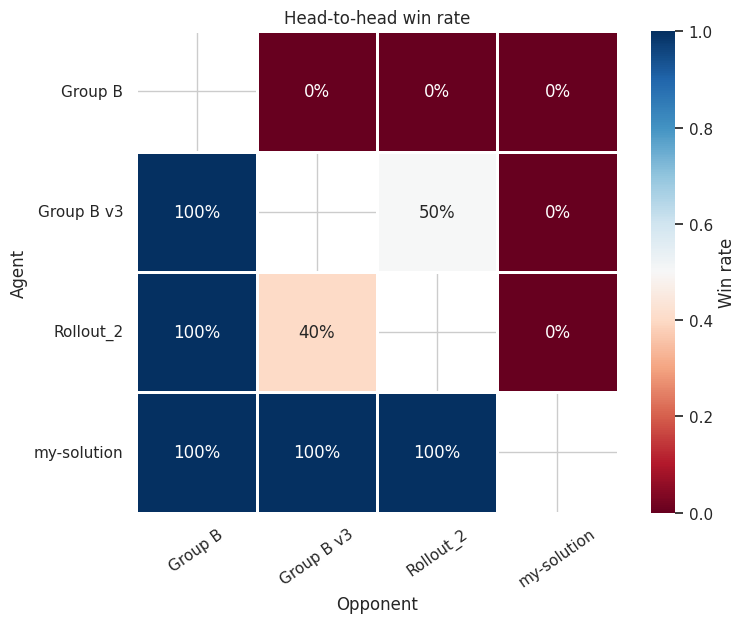

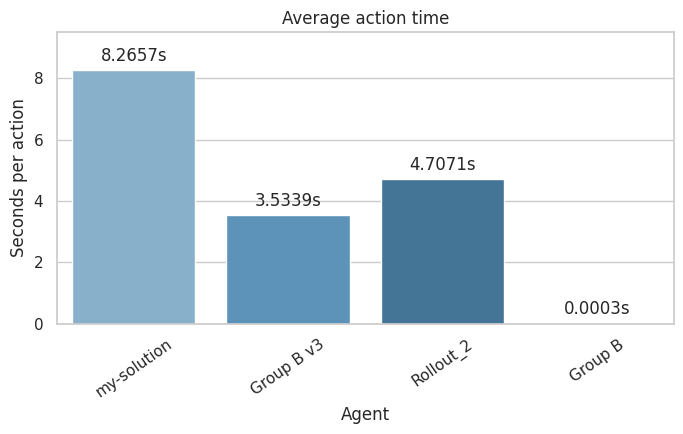

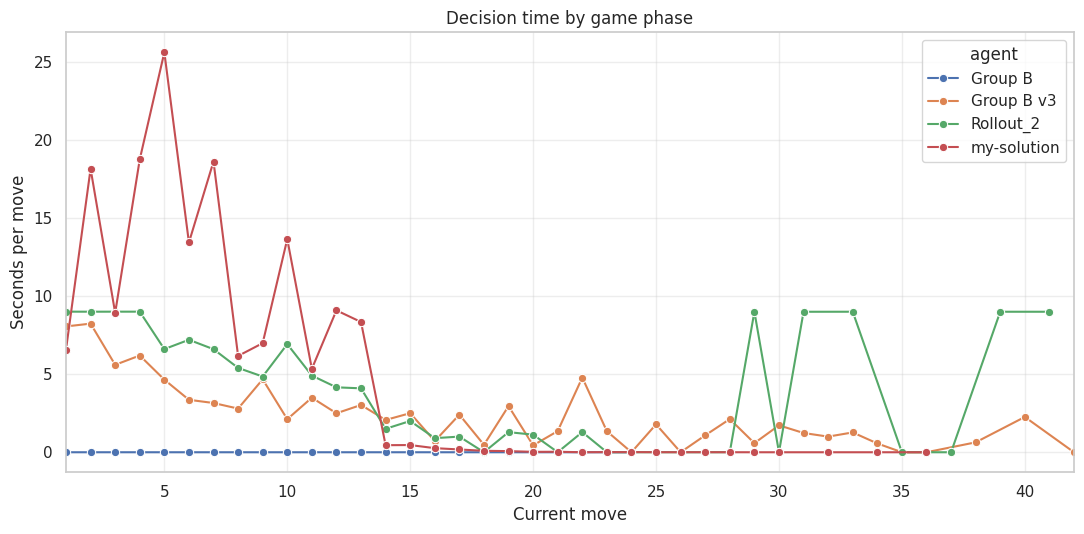

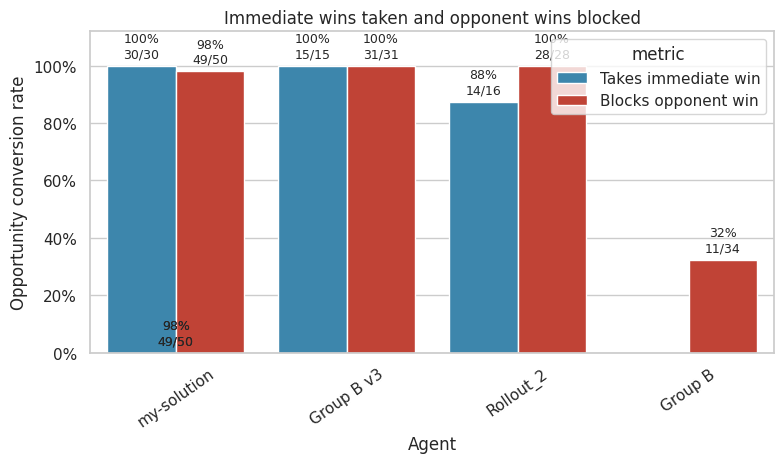

In [10]:

def plot_matrix(rows: list[dict], agent_names: list[str], metric: str, title: str, cmap: str = "RdBu") -> None:
      index = {name: idx for idx, name in enumerate(agent_names)}
      matrix = np.full((len(agent_names), len(agent_names)), np.nan)

      for row in rows:
          matrix[index[row["agent"]], index[row["opponent"]]] = row[metric]

      annotations = np.empty_like(matrix, dtype=object)
      for row_idx in range(len(agent_names)):
          for col_idx in range(len(agent_names)):
              value = matrix[row_idx, col_idx]
              annotations[row_idx, col_idx] = "" if np.isnan(value) else f"{value:.0%}"

      fig, ax = plt.subplots(figsize=(1.3 * len(agent_names) + 3, 1.1 * len(agent_names) + 2))
      sns.heatmap(
          matrix,
          ax=ax,
          annot=annotations,
          fmt="",
          cmap=cmap,
          vmin=0,
          vmax=1,
          center=0.5,
          linewidths=0.8,
          linecolor="white",
          square=True,
          cbar_kws={"label": "Win rate"},
          xticklabels=agent_names,
          yticklabels=agent_names,
      )
      ax.set_title(title)
      ax.set_xlabel("Opponent")
      ax.set_ylabel("Agent")
      ax.tick_params(axis="x", rotation=35)
      ax.tick_params(axis="y", rotation=0)
      plt.tight_layout()
      plt.show()


agent_names = list(agents)
plot_matrix(h2h_rows, agent_names, "win_rate", "Head-to-head win rate")

timing_rows = [
    {"agent": row["agent"], "avg_seconds_per_action": row["avg_seconds_per_action"]}
    for row in standings_rows
]
timing_df = pd.DataFrame(timing_rows)

fig, ax = plt.subplots(figsize=(max(7, len(timing_rows) * 1.5), 4.5))
sns.barplot(
    data=timing_df,
    x="agent",
    y="avg_seconds_per_action",
    ax=ax,
    palette="Blues_d",
    hue="agent",
    legend=False,
)

for patch in ax.patches:
    height = patch.get_height()
    if patch is not None and np.isfinite(height):
        ax.annotate(
            f"{height:.4f}s",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
        )

ax.set_ylabel("Seconds per action")
ax.set_xlabel("Agent")
ax.set_title("Average action time")
ax.tick_params(axis="x", rotation=35)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

phase_timing_rows = []
for game in results:
    for timing in game.timings:
        phase_timing_rows.append(
            {
                "agent": timing.agent,
                "move_number": timing.move_number,
                "seconds": timing.seconds,
            }
        )

phase_timing_df = pd.DataFrame(phase_timing_rows)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(
    data=phase_timing_df,
    x="move_number",
    y="seconds",
    hue="agent",
    marker="o",
    errorbar=None,
    ax=ax,
)
ax.set_xlabel("Current move")
ax.set_ylabel("Seconds per move")
ax.set_title("Decision time by game phase")
ax.set_xlim(1, MAX_MOVES)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

tactical_rows = []
for row in standings_rows:
    tactical_rows.append(
        {
            "agent": row["agent"],
            "metric": "Takes immediate win",
            "rate": row["immediate_win_take_rate"],
            "successes": row["wins_taken"],
            "opportunities": row["win_opportunities"],
        }
    )
    tactical_rows.append(
        {
            "agent": row["agent"],
            "metric": "Blocks opponent win",
            "rate": row["opponent_win_block_rate"],
            "successes": row["blocks_made"],
            "opportunities": row["block_opportunities"],
        }
    )

tactical_df = pd.DataFrame(tactical_rows)
agent_order = [row["agent"] for row in standings_rows]
metric_order = ["Takes immediate win", "Blocks opponent win"]

fig, ax = plt.subplots(figsize=(max(8, len(standings_rows) * 1.8), 4.8))
sns.barplot(
    data=tactical_df,
    x="agent",
    y="rate",
    hue="metric",
    order=agent_order,
    hue_order=metric_order,
    ax=ax,
    palette=["#2b8cbe", "#d7301f"],
)

for patch in ax.patches:
    if patch is None:
        continue

    height = patch.get_height()
    if not np.isfinite(height):
        continue

    x_center = patch.get_x() + patch.get_width() / 2
    agent_idx = int(round(x_center))
    if agent_idx < 0 or agent_idx >= len(agent_order):
        continue

    agent = agent_order[agent_idx]

    # Seaborn draws hue bars offset around each x tick. Negative offset is first hue,
    # positive offset is second hue.
    tick_center = agent_idx
    offset = x_center - tick_center
    metric = metric_order[0] if offset < 0 else metric_order[1]

    row_match = tactical_df[
        (tactical_df["agent"] == agent) & (tactical_df["metric"] == metric)
    ]

    if row_match.empty:
        continue

    row = row_match.iloc[0]
    label = f"{row['rate']:.0%}\n{int(row['successes'])}/{int(row['opportunities'])}"

    ax.annotate(
        label,
        (x_center, height),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_ylim(0, 1.12)
ax.set_ylabel("Opportunity conversion rate")
ax.set_xlabel("Agent")
ax.set_title("Immediate wins taken and opponent wins blocked")
ax.tick_params(axis="x", rotation=35)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
plt.show()